# PoDP Exploratory Data Analysis

This notebook explores the **Paired omics Data Platform (PoDP)** project records
found in `PoDP/*.json`. Each JSON file is one submitted project that links a
microbial **genome/metagenome** collection to a **GNPS/MassIVE metabolomics**
dataset, and (optionally) documents specific **biosynthetic gene cluster (BGC)
↔ MS2 spectrum** links.

Questions this notebook answers:

1. How many project records are there, and what does one look like?
2. How many linked genomics ↔ metabolomics *pairs* exist (`genome_metabolome_links`)?
3. How many BGC↔MS2 links exist, and how many are backed by *verified*
   experimental evidence?
4. What other labels are already present in the data (genome type, extraction
   method, instrumentation, ionization, medium, institution, ...), and how can
   we aggregate the messy free-text versions of these into meaningful
   categories?


In [ ]:
import json
import glob
import re
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("data/PoDP/json_descriptors")   # run this notebook from the repo root
assert DATA_DIR.exists(), f"Can't find {DATA_DIR.resolve()} -- run notebook from the project root"

json_files = sorted(DATA_DIR.glob("*.json"))
print(f"Found {len(json_files)} PoDP project JSON files")


## 1. Load all project records

Each filename is `{project_uuid}.{version}.json`. We load every record into memory as a list of dicts, keeping the source filename for traceability.

In [2]:
projects = []
for fp in json_files:
    with open(fp) as fh:
        d = json.load(fh)
    d["_source_file"] = fp.name
    d["_project_id"] = fp.stem.rsplit(".", 1)[0]  # uuid without the trailing version
    projects.append(d)

print(f"Loaded {len(projects)} project records")
print("Top-level keys seen across records:")
key_counts = Counter()
for p in projects:
    key_counts.update(p.keys())
for k, v in key_counts.most_common():
    print(f"  {k:28s} present in {v}/{len(projects)} records")


Loaded 76 project records
Top-level keys seen across records:
  version                      present in 76/76 records
  personal                     present in 76/76 records
  metabolomics                 present in 76/76 records
  experimental                 present in 76/76 records
  genomes                      present in 76/76 records
  genome_metabolome_links      present in 76/76 records
  proteomes                    present in 76/76 records
  _source_file                 present in 76/76 records
  _project_id                  present in 76/76 records
  BGC_MS2_links                present in 41/76 records


In [3]:
# Peek at a single record to understand the schema
import textwrap
sample = projects[0]
print(sample["_source_file"])
print(textwrap.shorten(json.dumps(sample, indent=2), width=1500, placeholder=" ...[truncated]"))


017c0466-e5d3-4792-a445-973d9dbe1b8b.1.json
{ "version": "3", "personal": { "PI_name": "Leticia Costa-lotufo", "submitter_email": "pireskarine@yahoo.com.br", "PI_institution": "Universidade de S\u00e3o Paulo Instituto de Bioci\u00eancias", "submitter_orcid": "https://orcid.org/0000-0003-3988-9241", "submitter_name": "Karine Pires", "submitter_name_secondary": "Leticia Costa-lotufo", "submitter_email_secondary": "costalotufo@gmail.com", "PI_email": "costalotufo@gmail.com" }, "metabolomics": { "project": { "GNPSMassIVE_ID": "MSV000079015", "MaSSIVE_URL": "https://gnps.ucsd.edu/ProteoSAFe/result.jsp?task=b352c72f1df44b87a45f7313aa73d5ce&view=advanced_view" } }, "experimental": { "extraction_methods": [ { "solvents": [ { "solvent": "http://purl.obolibrary.org/obo/CHEBI_27750", "ratio": 1 } ], "extracted_material": "supernatant", "extraction_method": "EtOAc" }, { "solvents": [ { "ratio": 1, "solvent": "http://purl.obolibrary.org/obo/CHEBI_28885" } ], "extracted_material": "supernatant", "ex

## 2. Linked genomics ↔ metabolomics pairs

Each project's `genome_metabolome_links` list is the literal pairing of a
`genome_label` (a genome/metagenome in the `genomes` block) with a
`metabolomics_file` (a raw MS file inside the project's GNPS/MassIVE dataset).
Each entry **is** one paired genomics–metabolomics data point.


In [4]:
gm_link_rows = []
for p in projects:
    for link in p.get("genome_metabolome_links", []) or []:
        row = dict(link)
        row["_project_id"] = p["_project_id"]
        row["_massive_id"] = p.get("metabolomics", {}).get("project", {}).get("GNPSMassIVE_ID")
        gm_link_rows.append(row)

gm_links = pd.DataFrame(gm_link_rows)
print(f"Total genomics<->metabolomics pairs (genome_metabolome_links rows): {len(gm_links)}")
print(f"Projects contributing at least one pair: {gm_links['_project_id'].nunique()} / {len(projects)}")
gm_links.head()


Total genomics<->metabolomics pairs (genome_metabolome_links rows): 4966
Projects contributing at least one pair: 76 / 76


,genome_label,metabolomics_file,extraction_method_label,instrumentation_method_label,sample_preparation_label,_project_id,_massive_id,proteome_label
0,Salinispora sp. BRA172,ftp://massive.ucsd.edu/MSV000079015/raw/Brazil...,EtOAc,6520 Quadrupole Time-of-Flight LC/MS,A1 medium,017c0466-e5d3-4792-a445-973d9dbe1b8b,MSV000079015,NaN
1,Salinispora sp. BRA190,ftp://massive.ucsd.edu/MSV000079015/raw/Brazil...,EtOAc,6520 Quadrupole Time-of-Flight LC/MS,A1 medium,017c0466-e5d3-4792-a445-973d9dbe1b8b,MSV000079015,NaN
2,Salinispora sp. BRA258,ftp://massive.ucsd.edu/MSV000079015/raw/Brazil...,EtOAc,6520 Quadrupole Time-of-Flight LC/MS,A1 medium,017c0466-e5d3-4792-a445-973d9dbe1b8b,MSV000079015,NaN
3,Streptomyces sp. CNB091,ftp://massive.ucsd.edu/MSV000083081/peak/CNB09...,Streptophenazine extraction,Streptophenazines,Streptomyces,03087dd9-2996-4bec-a3cc-88f71babc3a2,MSV000083081,NaN
4,Streptomyces sp. CNB091,ftp://massive.ucsd.edu/MSV000083081/peak/M1146...,Streptophenazine extraction,Streptophenazines,Streptomyces,03087dd9-2996-4bec-a3cc-88f71babc3a2,MSV000083081,NaN


count     76.000000
mean      65.342105
std      131.027280
min        1.000000
25%        2.750000
50%       10.000000
75%       44.000000
max      620.000000
dtype: float64


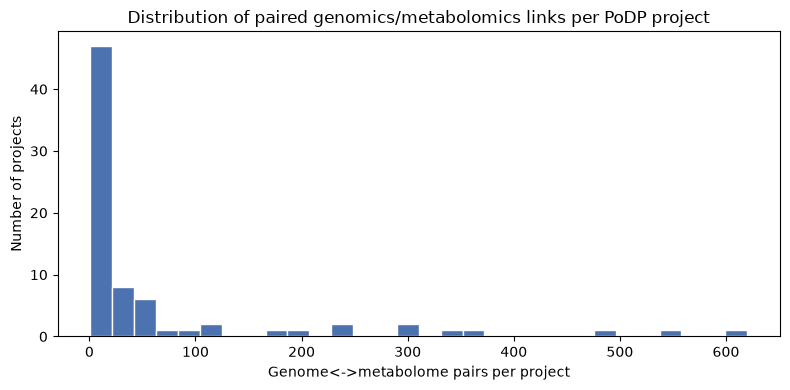

In [5]:
pairs_per_project = gm_links.groupby("_project_id").size().sort_values(ascending=False)
print(pairs_per_project.describe())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pairs_per_project, bins=30, color="#4C72B0", edgecolor="white")
ax.set_xlabel("Genome<->metabolome pairs per project")
ax.set_ylabel("Number of projects")
ax.set_title("Distribution of paired genomics/metabolomics links per PoDP project")
plt.tight_layout()
plt.show()


## 3. BGC ↔ MS2 spectral links

A smaller subset of projects additionally document explicit
**biosynthetic gene cluster (BGC) to MS2 spectrum** links in `BGC_MS2_links`.
Each entry records a `link` type, a free-text `known_link` description, an
optional `MIBiG_number`, the `MS2_URL`/`MS2_scan` pointing at the actual
supporting spectrum, and a `verification` list describing the strength of
evidence behind the link.

We treat a BGC-MS2 link as having a **verified spectral link** when it
actually points at a spectrum (`MS2_URL` and/or `MS2_scan` present) *and*
carries at least one non-empty `verification` entry.


In [6]:
bgc_rows = []
for p in projects:
    for link in p.get("BGC_MS2_links", []) or []:
        row = dict(link)
        row["_project_id"] = p["_project_id"]
        verification = row.get("verification", [])
        if isinstance(verification, str):
            verification = [verification]
        row["verification"] = verification
        row["mibig_number"] = (row.get("BGC_ID") or {}).get("MIBiG_number")
        row["has_ms2_pointer"] = bool(row.get("MS2_URL") or row.get("MS2_scan"))
        row["has_verification"] = bool(verification)
        row["verified_ms2_link"] = row["has_ms2_pointer"] and row["has_verification"]
        bgc_rows.append(row)

bgc_links = pd.DataFrame(bgc_rows)
n_projects_with_bgc = bgc_links["_project_id"].nunique() if len(bgc_links) else 0

print(f"Total BGC_MS2_links entries: {len(bgc_links)}")
print(f"Projects with at least one BGC_MS2_links entry: {n_projects_with_bgc} / {len(projects)}")
print(f"BGC entries with a verified MS2 spectral link: {int(bgc_links['verified_ms2_link'].sum())}")
print(f"BGC entries with a MIBiG accession: {bgc_links['mibig_number'].notna().sum()}")
bgc_links[["_project_id", "link", "mibig_number", "has_ms2_pointer", "has_verification", "verified_ms2_link"]].head(10)


Total BGC_MS2_links entries: 115
Projects with at least one BGC_MS2_links entry: 33 / 76
BGC entries with a verified MS2 spectral link: 67
BGC entries with a MIBiG accession: 82


,_project_id,link,mibig_number,has_ms2_pointer,has_verification,verified_ms2_link
0,03087dd9-2996-4bec-a3cc-88f71babc3a2,GNPS molecular family,BGC0002010,False,True,False
1,08a05264-7f06-4821-b4ad-bfd4ecb3bd34,GNPS molecular family,BGC0001766,False,True,False
2,08a05264-7f06-4821-b4ad-bfd4ecb3bd34,GNPS molecular family,NaN,False,True,False
3,0fa2c5fc-d1ce-431a-8445-fa3b6573e240,single molecule,BGC0000289,True,True,True
4,0fa2c5fc-d1ce-431a-8445-fa3b6573e240,single molecule,BGC0000529,True,True,True
5,0ff7a302-49af-4130-a440-59e284d4d365,GNPS molecular family,BGC0001766,False,True,False
6,0ff7a302-49af-4130-a440-59e284d4d365,GNPS molecular family,NaN,False,True,False
7,0ff7a302-49af-4130-a440-59e284d4d365,GNPS molecular family,NaN,False,True,False
8,0ff7a302-49af-4130-a440-59e284d4d365,GNPS molecular family,NaN,False,True,False
9,0ff7a302-49af-4130-a440-59e284d4d365,GNPS molecular family,NaN,False,True,False


In [7]:
# Breakdown of the verification evidence categories (a link can carry multiple types of evidence)
verification_counts = Counter()
for v_list in bgc_links["verification"]:
    verification_counts.update(v_list)

verification_df = (
    pd.Series(verification_counts, name="count")
    .sort_values(ascending=False)
    .rename_axis("verification_type")
    .reset_index()
)
verification_df


,verification_type,count
0,Experimentally validated with NMR and/or detai...,93
1,Bioinformatically inferred through comparative...,55
2,"Experimentally validated with knockouts, heter...",39
3,Evidence as indicated in MIBiG,38


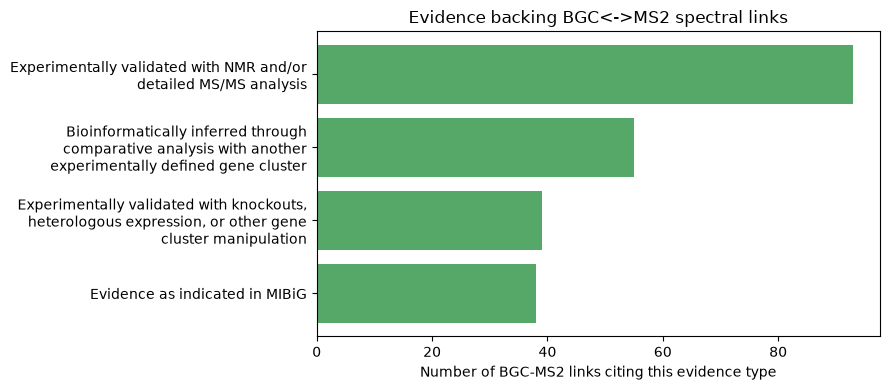

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(verification_df["verification_type"].str.wrap(45), verification_df["count"], color="#55A868")
ax.invert_yaxis()
ax.set_xlabel("Number of BGC-MS2 links citing this evidence type")
ax.set_title("Evidence backing BGC<->MS2 spectral links")
plt.tight_layout()
plt.show()


## 4. Other inherent labels, and aggregating them meaningfully

Beyond the pairing counts, every project record already carries a handful of
categorical/free-text labels we can mine:

- **Genome type** (`genomes[].genome_ID.genome_type`): `genome`,
  `metagenome`, `metagenome-assembled genome` — already a clean controlled
  vocabulary.
- **Extraction method / instrumentation method / ionization type**
  (`experimental.*`): free text entered by submitters, so the same method
  appears under many spellings (e.g. `MeOH`, `Methanol`, `EtOAc`,
  `Ethyl acetate`, `TOF`, `ToF`, `QToF`). We normalize these with a small
  synonym map into meaningful buckets.
- **Medium type** (`solid` / `liquid` / `metagenome`) — already clean.
- **Submitting institution** (`personal.PI_institution`) — free text, also
  benefits from light normalization (e.g. "UCSD" vs "University of
  California San Diego" vs "University of California, San Diego").


In [9]:
# --- Genome type (already a clean label) ---
genome_rows = []
for p in projects:
    for g in p.get("genomes", []) or []:
        genome_rows.append({
            "_project_id": p["_project_id"],
            "genome_label": g.get("genome_label"),
            "genome_type": (g.get("genome_ID") or {}).get("genome_type"),
        })
genomes_df = pd.DataFrame(genome_rows)

genome_type_counts = genomes_df["genome_type"].value_counts()
print(f"Total genome/metagenome entries across all projects: {len(genomes_df)}")
genome_type_counts


Total genome/metagenome entries across all projects: 2634


genome_type
metagenome                     1306
genome                         1286
metagenome-assembled genome      42
Name: count, dtype: int64

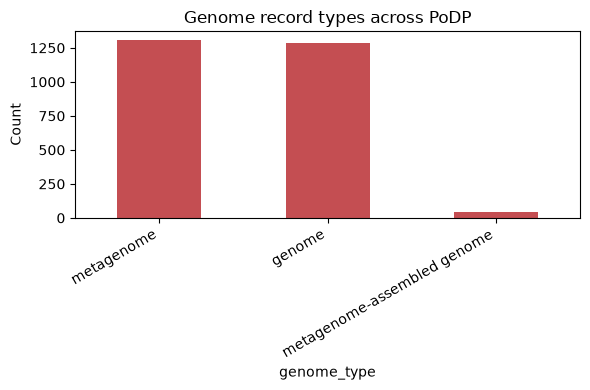

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
genome_type_counts.plot(kind="bar", ax=ax, color="#C44E52")
ax.set_ylabel("Count")
ax.set_title("Genome record types across PoDP")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [11]:
# --- Extraction method: normalize free text into meaningful buckets ---
extraction_method_map = {
    r"meoh|methanol": "Methanol",
    r"etoac|ethyl\s*acetate": "Ethyl acetate",
    r"buoh|butanol": "Butanol",
    r"dcm|dichloromethane": "Dichloromethane (DCM) mix",
    r"\bxad\b": "XAD resin",
    r"\bspe\b": "SPE",
    r"h2o|water": "Aqueous",
}

def normalize_label(raw, pattern_map, default="Other / unclassified"):
    if not raw:
        return default
    text = str(raw).lower()
    for pattern, bucket in pattern_map.items():
        if re.search(pattern, text):
            return bucket
    return default

extraction_rows = []
for p in projects:
    for m in (p.get("experimental", {}).get("extraction_methods") or []):
        raw = m.get("extraction_method")
        extraction_rows.append({
            "_project_id": p["_project_id"],
            "raw_label": raw,
            "extraction_bucket": normalize_label(raw, extraction_method_map),
        })
extraction_df = pd.DataFrame(extraction_rows)

print("Raw label -> normalized bucket (sample):")
display_cols = extraction_df.drop_duplicates("raw_label")[["raw_label", "extraction_bucket"]]
print(display_cols.to_string(index=False))
print()
extraction_bucket_counts = extraction_df["extraction_bucket"].value_counts()
extraction_bucket_counts


Raw label -> normalized bucket (sample):
                                   raw_label         extraction_bucket
                                       EtOAc             Ethyl acetate
                                        BuOH                   Butanol
                 Streptophenazine extraction      Other / unclassified
                                   non polar      Other / unclassified
                                        MeOH                  Methanol
                                          BB      Other / unclassified
                         Liquid-liquid EtOAc             Ethyl acetate
                               Ethyl acetate             Ethyl acetate
                                EthylAcetate             Ethyl acetate
                                         DCM Dichloromethane (DCM) mix
                                     Butanol                   Butanol
                                    Methanol                  Methanol
                                    

extraction_bucket
Other / unclassified         46
Methanol                     24
Ethyl acetate                18
Butanol                       9
XAD resin                     4
SPE                           3
Dichloromethane (DCM) mix     2
Aqueous                       1
Name: count, dtype: int64

In [12]:
# --- Instrumentation method: normalize TOF/QTOF/Orbitrap/IonTrap spelling variants ---
instrumentation_map = {
    r"qtof|q-tof|q\s*tof": "QTOF",
    r"\btof\b": "TOF",
    r"orbitrap": "Orbitrap",
    r"iontrap|ion trap": "Ion Trap",
    r"lc-ms|lcms": "LC-MS (unspecified)",
}

instrumentation_rows = []
for p in projects:
    for m in (p.get("experimental", {}).get("instrumentation_methods") or []):
        raw = m.get("instrumentation_method")
        instrumentation_rows.append({
            "_project_id": p["_project_id"],
            "raw_label": raw,
            "instrument_bucket": normalize_label(raw, instrumentation_map),
        })
instrumentation_df = pd.DataFrame(instrumentation_rows)
instrument_bucket_counts = instrumentation_df["instrument_bucket"].value_counts()
instrument_bucket_counts


instrument_bucket
Other / unclassified    37
TOF                     14
LC-MS (unspecified)     12
QTOF                    12
Orbitrap                 6
Ion Trap                 2
Name: count, dtype: int64

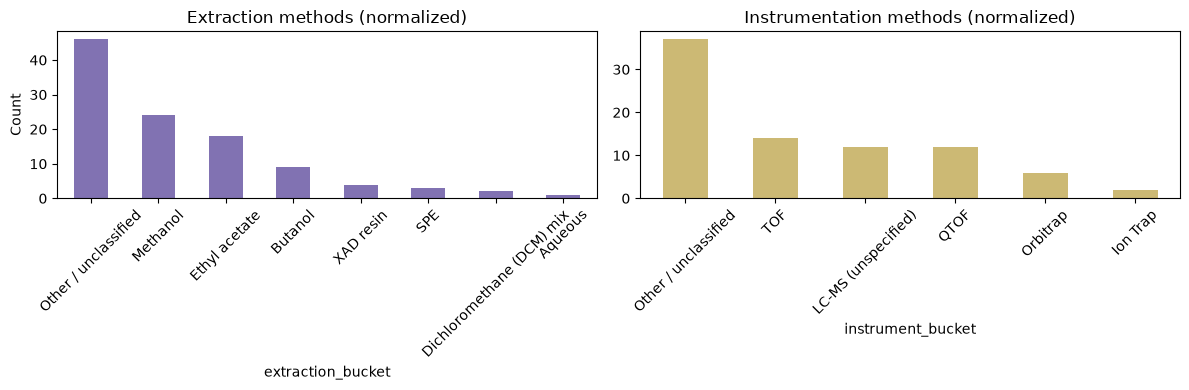

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
extraction_bucket_counts.plot(kind="bar", ax=axes[0], color="#8172B2")
axes[0].set_title("Extraction methods (normalized)")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

instrument_bucket_counts.plot(kind="bar", ax=axes[1], color="#CCB974")
axes[1].set_title("Instrumentation methods (normalized)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


In [14]:
# --- Submitting institution: light normalization of near-duplicate names ---
institution_map = {
    r"university of california,?\s*san diego|\bucsd\b": "UC San Diego",
    r"scripps institution of oceanography": "Scripps Institution of Oceanography",
}

institution_rows = []
for p in projects:
    raw = p.get("personal", {}).get("PI_institution")
    institution_rows.append({
        "_project_id": p["_project_id"],
        "raw_label": raw,
        "institution_bucket": normalize_label(raw, institution_map, default=raw or "Unknown"),
    })
institution_df = pd.DataFrame(institution_rows)
institution_counts = institution_df["institution_bucket"].value_counts()
print(f"Unique raw institution strings: {institution_df['raw_label'].nunique()}")
print(f"Unique institutions after normalization: {institution_df['institution_bucket'].nunique()}")
institution_counts.head(10)


Unique raw institution strings: 46
Unique institutions after normalization: 41


institution_bucket
UC San Diego                                       19
Leiden University (Institute of Biology Leiden)     4
University of Nottingham                            3
Scripps Institution of Oceanography                 3
University of Wisconsin-Madison                     3
Technische Universität Berlin                       3
ETH Zurich                                          3
Memorial University of Newfoundland                 2
University of California                            2
Universidade de São Paulo                           2
Name: count, dtype: int64

## 5. Per-project summary table

A tidy, one-row-per-project rollup combining everything above — useful as a
starting point for downstream filtering/joining (e.g. "give me every project
with a verified BGC-MS2 link AND more than 20 paired samples").


In [15]:
summary_rows = []
for p in projects:
    pid = p["_project_id"]
    n_genomes = len(p.get("genomes", []) or [])
    n_pairs = len(p.get("genome_metabolome_links", []) or [])
    bgc_entries = p.get("BGC_MS2_links", []) or []
    n_bgc = len(bgc_entries)
    n_verified = sum(
        1 for link in bgc_entries
        if (link.get("MS2_URL") or link.get("MS2_scan"))
        and (link.get("verification") if isinstance(link.get("verification"), list) else [link.get("verification")]) not in ([], [None])
    )
    summary_rows.append({
        "project_id": pid,
        "massive_id": p.get("metabolomics", {}).get("project", {}).get("GNPSMassIVE_ID"),
        "PI_institution": p.get("personal", {}).get("PI_institution"),
        "n_genomes": n_genomes,
        "n_genome_metabolome_pairs": n_pairs,
        "n_BGC_MS2_links": n_bgc,
        "n_verified_BGC_MS2_links": n_verified,
    })

project_summary = pd.DataFrame(summary_rows).sort_values("n_genome_metabolome_pairs", ascending=False)
project_summary.reset_index(drop=True, inplace=True)
project_summary


,project_id,massive_id,PI_institution,n_genomes,n_genome_metabolome_pairs,n_BGC_MS2_links,n_verified_BGC_MS2_links
0,5e920f02-2ae7-4d58-a4b9-fc76740958cd,MSV000082045,"University of California, San Diego",303,620,0,0
1,cd327ceb-f92b-4cd3-a545-39d29c602b6b,MSV000082969,"University of California, San Diego",556,556,0,0
2,50f9540c-9c9c-44e6-956c-87eabc960d7b,MSV000080179,UCSD,481,481,0,0
3,297c364c-b154-4edd-a7d5-68decf9effa2,MSV000078836,University of Bonn,120,360,9,0
4,0ff7a302-49af-4130-a440-59e284d4d365,MSV000078839,University of Nottingham,39,351,5,0
...,...,...,...,...,...,...,...
71,d0f1add5-5b16-4f78-9b93-0d1d9c9bcb59,MSV000086050,"Scripps Institution of Oceanography, Universit...",1,1,1,0
72,eaebc14f-4288-44e1-971a-b29ccb8a504f,MSV000079139,Leiden University (Institute of Biology Leiden),1,1,1,1
73,db830284-7b69-4eab-8185-76fc2554dd7e,MSV000083295,Instituto de Investigaciones Cientificas y Ser...,1,1,0,0
74,faafed8f-bcdc-4c56-b3b2-676e4d2ddcc6,MSV000082988,Leiden University (Institute of Biology Leiden),1,1,1,1


## 6. Headline answers

Recap of the specific questions asked at the top of the notebook.


In [16]:
total_pairs = len(gm_links)
total_bgc_ms2 = len(bgc_links)
total_verified = int(bgc_links["verified_ms2_link"].sum()) if len(bgc_links) else 0

print(f"Projects loaded:                                     {len(projects)}")
print(f"Total linked genomics<->metabolomics pairs:          {total_pairs}")
print(f"Total BGC_MS2_links entries:                          {total_bgc_ms2}")
print(f"BGC_MS2_links with a verified MS2 spectral link:      {total_verified}")
print(f"Projects with >=1 BGC_MS2_link:                       {n_projects_with_bgc}")


Projects loaded:                                     76
Total linked genomics<->metabolomics pairs:          4966
Total BGC_MS2_links entries:                          115
BGC_MS2_links with a verified MS2 spectral link:      67
Projects with >=1 BGC_MS2_link:                       33
